<a href="https://colab.research.google.com/github/hero941/econometrics-lab/blob/main/xbank.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Veriler çekiliyor...


/tmp/ipykernel_28939/4000305067.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  bist100 = yf.download("XU100.IS", start="2026-01-01", end=datetime.today().strftime('%Y-%m-%d'))
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_28939/4000305067.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  xbank = yf.download("XBANK.IS", start="2026-01-01", end=datetime.today().strftime('%Y-%m-%d')) # "XBANK.IS" ticker'ı varsayılmıştır.
[*********************100%***********************]  1 of 1 completed


Toplam veri sayısı: 63 gün
Tarih aralığı: 02.01.2026 - 01.04.2026

📊 30 GÜNLÜK KAYAN KORELASYON İSTATİSTİKLERİ
Ortalama Korelasyon  : 0.8240
Max Korelasyon       : 0.8960  (19.03.2026)
Min Korelasyon       : 0.6619  (13.02.2026)
Std Sapma            : 0.0806
Son Değer            : 0.8928  (01.04.2026)

Tüm Dönem Korelasyonu: 0.8146

📅 YILLIK KORELASYON
  2026: 0.8146


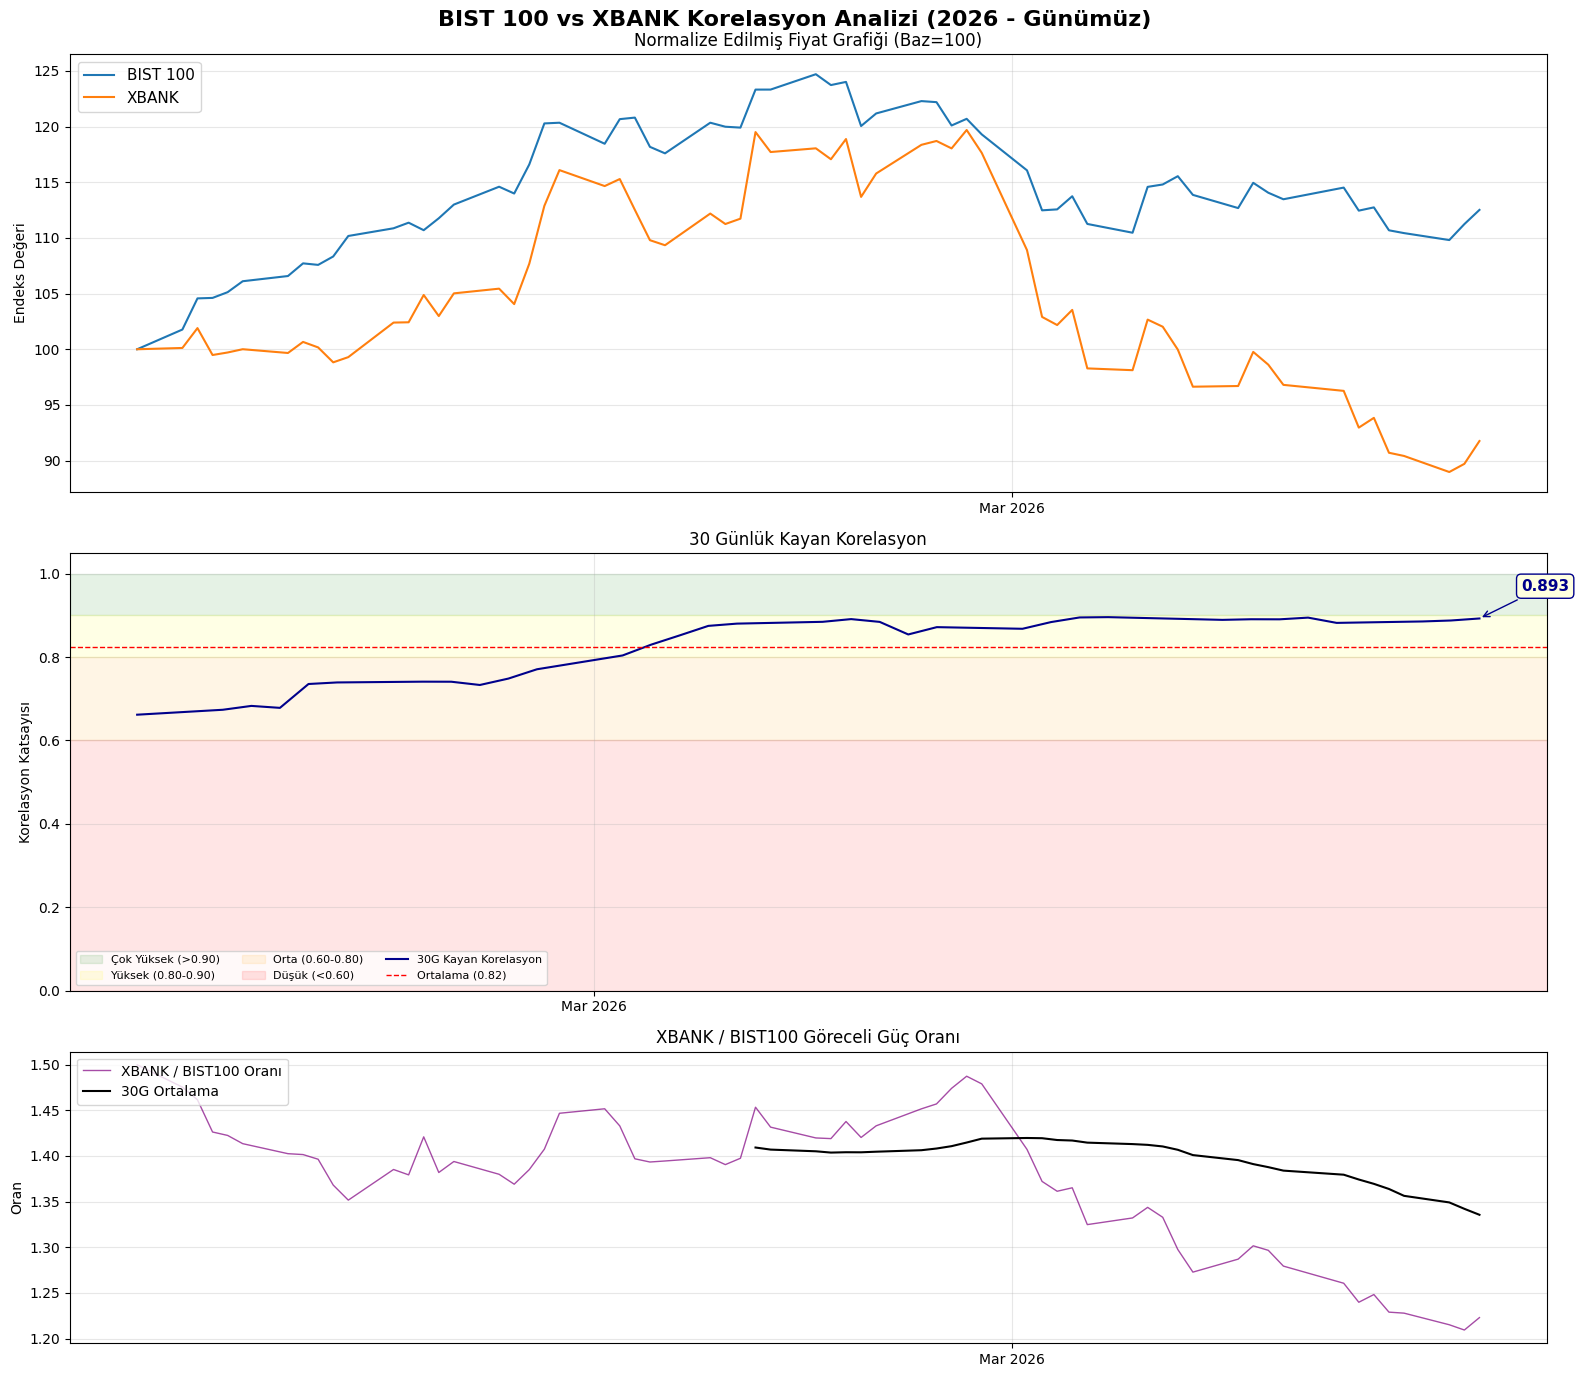


✅ Grafik kaydedildi: bist100_xbank_korelasyon.png

📋 SON 30 GÜNLÜK DETAYLAR
            BIST100_Degisim  XBANK_Degisim  Korelasyon_30G
Date                                                      
2026-02-18             0.23           1.55            0.68
2026-02-19            -3.20          -4.37            0.74
2026-02-20             0.94           1.85            0.74
2026-02-23             0.92           2.23            0.74
2026-02-24            -0.08           0.29            0.74
2026-02-25            -1.71          -0.56            0.73
2026-02-26             0.50           1.40            0.75
2026-02-27            -1.16          -1.71            0.77
2026-03-02            -2.71          -7.43            0.80
2026-03-03            -3.09          -5.51            0.83
2026-03-04             0.08          -0.71            0.85
2026-03-05             1.05           1.33            0.88
2026-03-06            -2.19          -5.07            0.88
2026-03-09            -0.71          -

In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

# ============================================
# 1. VERİ ÇEKME
# ============================================
print("Veriler çekiliyor...")

bist100 = yf.download("XU100.IS", start="2026-01-01", end=datetime.today().strftime('%Y-%m-%d'))
xbank = yf.download("XBANK.IS", start="2026-01-01", end=datetime.today().strftime('%Y-%m-%d')) # "XBANK.IS" ticker'ı varsayılmıştır.

df = pd.DataFrame({
    'BIST100': bist100['Close'].squeeze(),
    'XBANK': xbank['Close'].squeeze()
}).dropna()

print(f"Toplam veri sayısı: {len(df)} gün")
print(f"Tarih aralığı: {df.index[0].strftime('%d.%m.%Y')} - {df.index[-1].strftime('%d.%m.%Y')}")

# ============================================
# 2. GETİRİ HESAPLAMA
# ============================================
returns = df.pct_change().dropna()

# ============================================
# 3. 30 GÜNLÜK KAYAN KORELASYON
# ============================================
rolling_30 = returns['BIST100'].rolling(window=30).corr(returns['XBANK'])

# ============================================
# 4. TEMEL İSTATİSTİKLER
# ============================================
print("\n" + "="*50)
print("📊 30 GÜNLÜK KAYAN KORELASYON İSTATİSTİKLERİ")
print("="*50) # Hatalı satır düzeltildi
print(f"Ortalama Korelasyon  : {rolling_30.mean():.4f}") # Eklendi
print(f"Max Korelasyon       : {rolling_30.max():.4f}  ({rolling_30.idxmax().strftime('%d.%m.%Y')})") # Eklendi
print(f"Min Korelasyon       : {rolling_30.min():.4f}  ({rolling_30.idxmin().strftime('%d.%m.%Y')})") # Eklendi
print(f"Std Sapma            : {rolling_30.std():.4f}")
print(f"Son Değer            : {rolling_30.iloc[-1]:.4f}  ({rolling_30.index[-1].strftime('%d.%m.%Y')})")

# Genel dönem korelasyonu
overall_corr = returns.corr().iloc[0, 1]
print(f"\nTüm Dönem Korelasyonu: {overall_corr:.4f}")

# Yıllık bazda korelasyon
print("\n" + "="*50)
print("📅 YILLIK KORELASYON")
print("="*50)
for year in returns.index.year.unique():
    yearly = returns[returns.index.year == year]
    if len(yearly) > 20:
        corr = yearly.corr().iloc[0, 1]
        print(f"  {year}: {corr:.4f}")

# ============================================
# 5. GRAFİK
# ============================================
fig, axes = plt.subplots(3, 1, figsize=(16, 14), gridspec_kw={'height_ratios': [3, 3, 2]})
fig.suptitle('BIST 100 vs XBANK Korelasyon Analizi (2026 - Günümüz)',
             fontsize=16, fontweight='bold', y=0.98)

# --- Grafik 1: Normalize Fiyat Karşılaştırması ---
norm = df / df.iloc[0] * 100
axes[0].plot(norm.index, norm['BIST100'], label='BIST 100', color='#1f77b4', linewidth=1.5)
axes[0].plot(norm.index, norm['XBANK'], label='XBANK', color='#ff7f0e', linewidth=1.5)
axes[0].set_title('Normalize Edilmiş Fiyat Grafiği (Baz=100)', fontsize=12)
axes[0].set_ylabel('Endeks Değeri')
axes[0].legend(loc='upper left', fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=3))

# --- Grafik 2: 30 Günlük Kayan Korelasyon ---
ax2 = axes[1]

# Renk kodlaması
ax2.axhspan(0.90, 1.00, alpha=0.1, color='green', label='Çok Yüksek (>0.90)')
ax2.axhspan(0.80, 0.90, alpha=0.1, color='yellow', label='Yüksek (0.80-0.90)')
ax2.axhspan(0.60, 0.80, alpha=0.1, color='orange', label='Orta (0.60-0.80)')
ax2.axhspan(0.00, 0.60, alpha=0.1, color='red', label='Düşük (<0.60)')

ax2.plot(rolling_30.index, rolling_30.values, color='darkblue', linewidth=1.5, label='30G Kayan Korelasyon')

# Ortalama çizgisi
ax2.axhline(y=rolling_30.mean(), color='red', linestyle='--', linewidth=1, label=f'Ortalama ({rolling_30.mean():.2f})')

# Son değer işaretleme
last_val = rolling_30.iloc[-1]
last_date = rolling_30.index[-1]
ax2.annotate(f'{last_val:.3f}',
             xy=(last_date, last_val),
             xytext=(30, 20), textcoords='offset points',
             fontsize=11, fontweight='bold', color='darkblue',
             arrowprops=dict(arrowstyle='->', color='darkblue'),
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='darkblue'))

ax2.set_title('30 Günlük Kayan Korelasyon', fontsize=12)
ax2.set_ylabel('Korelasyon Katsayısı')
ax2.set_ylim(0.0, 1.05)
ax2.legend(loc='lower left', fontsize=8, ncol=3)
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))

# --- Grafik 3: XBANK / BIST100 Oran Grafiği ---
ratio = df['XBANK'] / df['BIST100']
ratio_ma = ratio.rolling(window=30).mean()

axes[2].plot(ratio.index, ratio.values, color='purple', linewidth=1, alpha=0.7, label='XBANK / BIST100 Oranı')
axes[2].plot(ratio_ma.index, ratio_ma.values, color='black', linewidth=1.5, label='30G Ortalama')
axes[2].set_title('XBANK / BIST100 Göreceli Güç Oranı', fontsize=12)
axes[2].set_ylabel('Oran')
axes[2].legend(loc='upper left', fontsize=10)
axes[2].grid(True, alpha=0.3)
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[2].xaxis.set_major_locator(mdates.MonthLocator(interval=3))

plt.tight_layout()
plt.savefig('bist100_xbank_korelasyon.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Grafik kaydedildi: bist100_xbank_korelasyon.png")

# ============================================
# 6. SON 30 GÜNLÜK DETAY TABLO
# ============================================
print("\n" + "="*50)
print("📋 SON 30 GÜNLÜK DETAYLAR") # Hatalı satır düzeltildi
print("="*50)

last_30 = pd.DataFrame({
    'BIST100_Degisim': returns['BIST100'].tail(30) * 100, # Assuming this is intended
    'XBANK_Degisim': returns['XBANK'].tail(30) * 100, # Assuming this is intended
    'Korelasyon_30G': rolling_30.tail(30)
})

print(last_30.to_string(float_format='%.2f'))

# ============================================
# 7. SİNYAL ÜRETİCİ
# ============================================
print("\n" + "="*50)
print("🚦 MEVCUT SİNYAL DEĞERLENDİRMESİ")
print("="*50)

son_korelasyon = rolling_30.iloc[-1]
ort_korelasyon = rolling_30.mean()

if son_korelasyon > 0.90:
    print(f"  Korelasyon: {son_korelasyon:.4f} → ÇOK YÜKSEK")
    print("  ➜ Piyasa tek yönlü hareket ediyor")
    print("  ➜ Endeks bazlı pozisyon yeterli")
elif son_korelasyon > 0.80:
    print(f"  Korelasyon: {son_korelasyon:.4f} → YÜKSEK")
    print("  ➜ Normal seviye, trend devam ediyor.") # Hatalı satır düzeltildi
elif son_korelasyon > 0.60: # Orta seviye için koşul eklendi
    print(f"  Korelasyon: {son_korelasyon:.4f} → ORTA")
    print("  ➜ Sektörel ayrışma başlıyor")
    print("  ➜ Geride kalan tarafta fırsat olabilir")
else:
    print(f"  Korelasyon: {son_korelasyon:.4f} → DÜŞÜK")
    print("  ➜ Güçlü ayrışma! Pair trade fırsatı")
    print("  ➜ Ortalamaya dönüş stratejisi değerlendir")

if son_korelasyon < ort_korelasyon - rolling_30.std():
    print("\n  ⚠️ Korelasyon ortalamanın 1 std altında → AYRIŞMA ALARMI")
elif son_korelasyon > ort_korelasyon + rolling_30.std():
    print("\n  ✅ Korelasyon ortalamanın 1 std üstünde → UYUM YÜKSEK")